In [1]:
import os
import cv2
import time
import math
import json 
import torch
import tiktoken
import torchvision
import numpy as np 
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.transforms import v2 
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import CosineAnnealingLR

from tqdm.notebook import tqdm

In [2]:
#defualt is highest
torch.set_float32_matmul_precision('high')

In [3]:
@dataclass
class TrainingConfiguration:
    '''
    Describes configuration of the training process
    '''
    batch_size: int = 128 
    grad_accumulation_steps: int = 2
    warmup_epochs: int = 1
    epochs_count: int = 10  
    init_learning_rate: float = 5e-4  # initial learning rate for lr scheduler
    weight_decay: float = .2
    betas = (0.9, 0.98)
    grad_clip: float = 1.0
    valid_interval: int = 1  
    data_root: str = "../datasets/cc3m" 
    num_workers: int = 10
    device: str = 'cuda:1'  
    model_dir: str = 'models_clip_cc3m_595k'
    log_dir: str = 'logs_clip_cc3m_595k'
    model_name : str = 'clip_base_patch16_224'
    
    #vit model hyperparameters
    img_size: int = 224
    patch_size: int = 16
    vit_dim: int = 768 
    vit_heads: int = 12 
    vit_encoder_layers: int = 12 
    dropout: float = 0.1

    #transformer hyperparameters
    context_length: int = 77
    transformer_width: int = 512
    transformer_heads: int = 8
    transformer_layers: int = 12

    projection_dim: int = 512


In [4]:
class FFN(nn.Module):
    
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        
    def forward(self,x):
        return self.feed_forward(x)

In [5]:
class MultiHeadAttention(nn.Module):
    
    def __init__(self, d_model: int, h: int, dropout: float):
        super().__init__()
        self.d_model = d_model
        self.h = h
        
        assert d_model%h ==0, "d_model should be divisible by h"
        
        self.d_k = d_model//h
        self.w_q = nn.Linear(d_model,d_model, bias= False)
        self.w_k = nn.Linear(d_model,d_model, bias= False)        
        self.w_v = nn.Linear(d_model, d_model, bias= False)  
        
        self.w_o = nn.Linear(d_model, d_model, bias= False)  
        self.dropout = nn.Dropout(dropout)
        
    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):
        d_k = query.shape[-1]
        scores = query@key.transpose(-2,-1)/math.sqrt(d_k)
        #print(query.shape,key.shape, value.shape, scores.shape, mask.shape)
        if mask is not None:
            scores.masked_fill_(mask==0, -1e9)
        scores = scores.softmax(dim=-1)
        
        ### do we need ?
        if dropout is not None:
            scores = dropout(scores)
            
        return scores@value,scores 
        
    def forward(self, q, k, v, mask):
        # batch, seq len, embed dim
        query = self.w_q(q)
        key = self.w_k(k)
        value = self.w_v(v)
        
        # batch, h, seq, d_k
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1,2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1,2)
        value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1,2)
        
        #x, scores = self.attention(query, key, value, mask, self.dropout)
        #using inbuilt flash attention
        x = F.scaled_dot_product_attention(query, key, value, attn_mask=mask, dropout_p=self.dropout.p)

        x = x.transpose(1,2).contiguous().view(x.shape[0], -1, self.h*self.d_k)
        
        return self.w_o(x)
        

In [6]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model:int, h:int, d_ff:int, dropout:float):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, h, dropout)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.layer_norm_1 = nn.LayerNorm(d_model)
        self.layer_norm_2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        x_ln = self.layer_norm_1(x)
        attention = self.attention(x_ln, x_ln, x_ln, mask)
        x = x + self.dropout(attention)
        
        ffn_out = self.ffn(self.layer_norm_2(x))
        x = x+ self.dropout(ffn_out)
        
        return x
        

In [7]:
class Transformer(nn.Module):
    def __init__(self,d_model:int, h:int, d_ff:int, dropout:float, N=6):
        super().__init__()
        
        self.encoder = nn.ModuleList(
            [
                EncoderBlock(d_model, h, d_ff, dropout)
                for _ in range(N)
            ]
        )
        
    
    def forward(self,x, mask=None):
        for layer in  self.encoder:
            x = layer(x, mask)
        return x
    

In [8]:
def img_to_patches(img, patch_size):
    bs, c, h, w = img.shape
    assert h % patch_size == 0 and w % patch_size == 0, "Image dimensions must be divisible by the patch size."
    num_patches_h = h // patch_size
    num_patches_w = w // patch_size
    img = img.reshape(bs, c, num_patches_h, patch_size, num_patches_w, patch_size)
    img = img.permute(0, 2, 4, 1, 3, 5).contiguous()  # (batch_size, num_patches_h, num_patches_w, channels, patch_size, patch_size)
    patches = img.view(bs, num_patches_h * num_patches_w, c * patch_size * patch_size)  # (batch_size, num_patches, patch_dim)
    return patches


In [9]:
class ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, projection_dim=512,
                  dim =768, heads=8, encoder_layers=12, dropout=0.1):
        super(ViT, self).__init__() 
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.linear_proj = nn.Linear(3*patch_size*patch_size, dim)
        self.transformer = Transformer(dim, heads, dim*4, dropout, encoder_layers)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.embedding = nn.Parameter(torch.randn(1, self.num_patches+1, dim))
        self.dropout = nn.Dropout(dropout)
        self.ln_pre = nn.LayerNorm(dim)
        self.ln_post = nn.LayerNorm(dim)
        self.projection_layer = nn.Parameter(torch.randn(dim, projection_dim))

    def forward(self, x):
        x = img_to_patches(x, self.patch_size)  # (batch_size, num_patches, patch_dim)
        x = self.linear_proj(x)  # (batch_size, num_patches, dim)
        cls_token = self.cls_token.repeat(x.shape[0], 1, 1)  # (batch_size, 1, dim)
        x = torch.cat((cls_token, x), dim=1)  # (batch_size, num_patches + 1, patch_dim)
        x = x + self.embedding  # (batch_size, num_patches + 1, dim)
        x = self.dropout(x)
        x = self.ln_pre(x)
        x = self.transformer(x)  # (batch_size, num_patches + 1, dim)
        x = self.ln_post(x)
        x = x[:, 0]  # (batch_size, dim)
        x = torch.matmul(x, self.projection_layer)
        return x

In [11]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, context_length, h,
                  d_ff, dropout, N, projection_dim):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Parameter(torch.randn(1, context_length, d_model))
        self.transformer = Transformer(d_model, h, d_ff, dropout, N)
        self.ln_post = nn.LayerNorm(d_model)
        self.projection_layer = nn.Parameter(torch.randn(d_model, projection_dim))

    def forward(self, x):
        masked = x.clone()
        masked[:,0]=-1
        pos = masked.argmax(dim=-1)

        x = self.token_embedding(x)  # (batch_size, seq_len, d_model)
        x = x + self.positional_embedding[:, :x.shape[1], :]  # (batch_size, seq_len, d_model)
        x = self.transformer(x)  # (batch_size, seq_len, d_model)
        x = self.ln_post(x)
        x = x[torch.arange(x.shape[0]), pos, :]  # (batch_size, d_model)
        x = torch.matmul(x, self.projection_layer)  # (batch_size, projection_dim)
        return x

In [12]:
class CLIP(nn.Module):
    def __init__(self, config: TrainingConfiguration, tokenizer: tiktoken.core.Encoding):
        super().__init__()
        self.image_encoder = ViT(
            img_size=config.img_size,
            patch_size=config.patch_size,
            projection_dim=config.projection_dim,
            dim =config.vit_dim,
            heads=config.vit_heads,
            encoder_layers=config.vit_encoder_layers,
            dropout=config.dropout
        )
        self.text_encoder = TextEncoder(
            vocab_size=tokenizer.n_vocab,
            d_model=config.transformer_width,
            context_length=config.context_length,
            h=config.transformer_heads,
            d_ff=config.transformer_width*4,
            dropout=config.dropout,
            N=config.transformer_layers,
            projection_dim=config.projection_dim,
        )
        self.logits_scale = nn.Parameter(torch.tensor(1.0))

        #self.initialize_weights()

    def forward(self, images, tokens):
        image_features = self.image_encoder(images)  # (batch_size, projection_dim)
        text_features = self.text_encoder(tokens)  # (batch_size, projection_dim)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        logit_scale = self.logits_scale.exp()
        logits_image = logit_scale * image_features @ text_features.t()  # (batch_size, batch_size)
        logits_text = logit_scale * text_features @ image_features.t()  # (batch_size, batch_size)

        #symmetric loss fn
        labels = torch.arange(image_features.shape[0], device=image_features.device)
        loss_image = F.cross_entropy(logits_image, labels)
        loss_text = F.cross_entropy(logits_text, labels)
        loss = (loss_image + loss_text) / 2

        return loss, loss_image, loss_text, logits_image, logits_text
    
    def initialize_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
            else:
                if 'layer' in name:
                    continue
                else:
                    nn.init.zeros_(p)

In [13]:
def transform():
    return v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.Resize((224, 224)),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [14]:
class DatasetClip(Dataset):
    def __init__(self, image_files: list, images_dir: str, tokenized_captions: np.ndarray, 
                 transform: torchvision.transforms.v2._container.Compose):
        self.images_dir = images_dir
        self.tokenized_captions = torch.tensor(tokenized_captions, dtype=torch.int32)
        self.image_files = image_files
        self.transform = transform

    def __getitem__(self, idx):
        image_path = os.path.join(self.images_dir, self.image_files[idx])
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transform(image)
        tokens = self.tokenized_captions[idx]
        return image, tokens

    def __len__(self):
        return len(self.image_files)

In [15]:
def imagenet_denormalize(image):
    """Convert ImageNet-normalized image (H, W, C) back to [0,1] RGB."""
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    image = (image * std) + mean
    return np.clip(image, 0.0, 1.0)


In [16]:
def get_caption(tokens, tokenizer):
    masked = tokens.clone()
    masked[0]=-1
    pos = masked.argmax()
    caption = tokenizer.decode(tokens[1:pos].numpy())
    return caption  

In [17]:
config = TrainingConfiguration()

In [18]:
tokenizer = tiktoken.get_encoding('gpt2')

In [19]:
with open(os.path.join(config.data_root, 'chat.json')) as f:
    data = json.load(f)

images_name  = []
for item in data:
    images_name.append(item['image'])

del data

In [20]:
tokenized_captions = np.load(os.path.join(config.data_root, 'tokenized_data.npy'))

In [21]:
train_size = int(0.95*len(images_name))
train_images = images_name[:train_size]
train_tokenized_captions = tokenized_captions[:train_size]

valid_images = images_name[train_size:]
valid_tokenized_captions = tokenized_captions[train_size:]  

In [22]:
train_dataset = DatasetClip(train_images, os.path.join(config.data_root, 'images'), train_tokenized_captions, transform())
valid_dataset = DatasetClip(valid_images, os.path.join(config.data_root, 'images'), valid_tokenized_captions, transform())

In [23]:
len(train_dataset), len(valid_dataset)

(565606, 29769)

In [24]:
img, tokens = train_dataset[1234]
img = imagenet_denormalize(img.permute(1, 2, 0).numpy())
caption = get_caption(tokens, tokenizer)

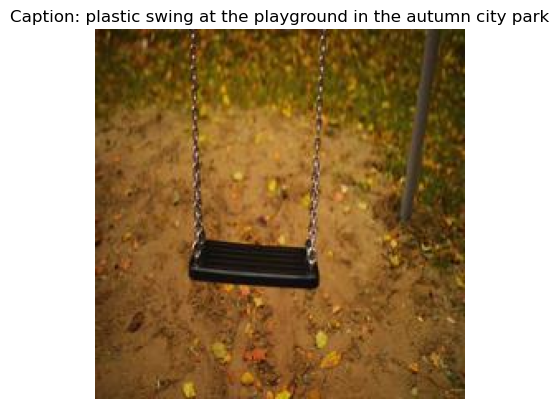

In [25]:
plt.imshow(img)
plt.axis('off')
plt.title(f'Caption: {caption}')
plt.show()

In [26]:
def train(
    train_config: TrainingConfiguration, model: CLIP, optimizer: torch.optim.Optimizer,
    train_loader: torch.utils.data.DataLoader, epoch_idx: int, global_step: int,
    lr_scheduler, summary_writer: SummaryWriter,
) -> tuple[float, int]:

    # change model in training mood
    model.train()
    # to get batch loss
    batch_loss = np.array([])
    norms = np.array([])
    batch_iterator = tqdm(train_loader, desc=f"Processing Epoch {epoch_idx}")
    for batch_idx, (imgs, tokens) in enumerate(batch_iterator):
        
        imgs = imgs.to(train_config.device)
        tokens = tokens.to(train_config.device)
            
        with torch.autocast(device_type=train_config.device, dtype=torch.bfloat16):
            # forward pass to the model
            loss, loss_image, loss_text, logits_image, logits_text = model(imgs, tokens)

        batch_loss = np.append(batch_loss, [loss.item()])
        loss = loss / train_config.grad_accumulation_steps
        loss.backward()
        norm = torch.nn.utils.clip_grad_norm_(model.parameters(), train_config.grad_clip)
        norms = np.append(norms, [norm.item()])
        
        if (batch_idx + 1) % train_config.grad_accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1
            if lr_scheduler:
                lr_scheduler.step()
            summary_writer.add_scalar('Learning Rate',optimizer.param_groups[0]['lr'] , global_step)
            summary_writer.add_scalar('Step/Train Loss', loss.item()*train_config.grad_accumulation_steps, global_step)


        batch_iterator.set_postfix({"loss": f"{loss.item()*train_config.grad_accumulation_steps:.3f}",\
                                     "grad_norm": f"{norm.item():.3f}"})

            
    epoch_loss = batch_loss.mean()
    epoch_norm = norms.mean()
    print('Epoch: {} Train Loss: {:.3f} Grad Norm: {:.3f}'.format(epoch_idx, epoch_loss, epoch_norm))
    return epoch_loss, global_step

In [27]:
def validation(
    train_config: TrainingConfiguration, model: CLIP,
    test_loader: torch.utils.data.DataLoader, epoch_idx: int
) -> float:

    # change model in training mood
    model.eval()
    # to get batch loss
    batch_loss = np.array([])
    with torch.no_grad():
        batch_iterator = tqdm(test_loader, desc=f"Validating Epoch {epoch_idx}")
        for batch_idx, (imgs, tokens) in enumerate(batch_iterator):

            imgs = imgs.to(train_config.device)
            tokens = tokens.to(train_config.device)
            
            with torch.autocast(device_type=train_config.device, dtype=torch.bfloat16):
                # forward pass to the model
                loss, loss_image, loss_text, logits_image, logits_text = model(imgs, tokens)

            
            batch_loss = np.append(batch_loss, [loss.item()])
            batch_iterator.set_postfix({"loss": f"{loss.item():.3f}"})

                
    epoch_loss = batch_loss.mean()
    print('Epoch: {} Valid Loss: {:.6f}'.format(epoch_idx, epoch_loss))
    return epoch_loss

In [28]:
def save_model(model, device, model_dir, model_file_name):
    

    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    model_path = os.path.join(model_dir, model_file_name)

    # make sure you transfer the model to cpu.
    if device == 'cuda':
        model.to('cpu')

    # save the state_dict
    torch.save(model.state_dict(), model_path)
    
    if device == 'cuda':
        model.to('cuda')
    
    return

In [29]:
def main(model,summary_writer,train_data,valid_data,optimizer,\
         training_configuration=TrainingConfiguration(), scheduler=None):
    
    train_loader = DataLoader(
        dataset=train_data, 
        batch_size=training_configuration.batch_size,
        num_workers=training_configuration.num_workers,
        shuffle=True
    )
    
    valid_loader = DataLoader(
        dataset=valid_data, 
        batch_size=training_configuration.batch_size,
        num_workers=training_configuration.num_workers
    )
    
    
    # send model to device (GPU/CPU)
    model.to(training_configuration.device)

    best_loss = torch.tensor(np.inf)
    
    t_begin = time.time()
    global_step = 0
    for epoch in range(training_configuration.epochs_count):
        
        # Train and visualize training images
        train_loss, global_step = train(training_configuration, model, optimizer, train_loader,\
                                         epoch, global_step, scheduler, summary_writer)
        summary_writer.add_scalar('Epoch/Train Loss', train_loss, epoch)
        
        # Validate
        if epoch % training_configuration.valid_interval == 0:
            valid_loss = validation(training_configuration, model, valid_loader, epoch)
            summary_writer.add_scalar('Epoch/Validation Loss', valid_loss, epoch)
            save_model(model, device=training_configuration.device,
                        model_dir=training_configuration.model_dir,
                        model_file_name= training_configuration.model_name+'_best.pt')
    
        elapsed_time = time.time() - t_begin
        speed_epoch = elapsed_time / (epoch + 1)
        eta = speed_epoch *training_configuration.epochs_count - elapsed_time

        #writing scalers to tensorboard
        summary_writer.add_scalar('Time Elapsed',elapsed_time, epoch)
        summary_writer.add_scalar('ETA',eta, epoch)
        

    print("Total time: {:.2f}".format(time.time() - t_begin))

In [30]:
train_config = TrainingConfiguration()

clip_model = CLIP(train_config, tokenizer)

In [31]:
summary_writer = SummaryWriter(log_dir=train_config.log_dir)

In [32]:
clip_model.to(train_config.device)
model = torch.compile(clip_model)
print('')

In [33]:
optimizer = torch.optim.AdamW(
    clip_model.parameters(),
    lr = train_config.init_learning_rate,
    weight_decay = train_config.weight_decay,
    betas = train_config.betas
)


In [34]:
def get_scheduler(optimizer, warmup_steps, total_steps, min_lr_ratio=0.1):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        cosine = 0.5 * (1 + math.cos(math.pi * progress))
        # clamp so it never goes below min_lr_ratio * base_lr
        return max(cosine, min_lr_ratio)
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [35]:
steps_per_epoch = math.ceil(len(train_dataset) /(train_config.batch_size*train_config.grad_accumulation_steps))
total_steps = steps_per_epoch * train_config.epochs_count  
warmup_steps = int(0.1 * total_steps)       

In [36]:
warmup_steps, total_steps

(2210, 22100)

In [37]:
scheduler = get_scheduler(optimizer, warmup_steps, total_steps)

In [38]:
main(model,summary_writer, train_dataset, valid_dataset, optimizer, train_config, scheduler)

Processing Epoch 0:   0%|          | 0/4419 [00:00<?, ?it/s]

W0421 11:34:41.440000 97029 site-packages/torch/_inductor/utils.py:1679] [0/1] Not enough SMs to use max_autotune_gemm mode
/home/neeraj/anaconda3/envs/gym/lib/python3.11/site-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Epoch: 0 Train Loss: 4.201 Grad Norm: 0.945


Validating Epoch 0:   0%|          | 0/233 [00:00<?, ?it/s]

/home/neeraj/anaconda3/envs/gym/lib/python3.11/site-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


...

Epoch: 8 Valid Loss: 1.742055


Processing Epoch 9:   0%|          | 0/4419 [00:00<?, ?it/s]

Epoch: 9 Train Loss: 1.118 Grad Norm: 1.615


Validating Epoch 9:   0%|          | 0/233 [00:00<?, ?it/s]

Epoch: 9 Valid Loss: 1.732556
Total time: 16833.00
